In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, KFold, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
import joblib


In [19]:
model = None

def train_model(file, balanced=False, show_cv_info = False):
    global model

    df = pd.read_csv(f'./../../dataset/{file}.csv')

    TARGET = "will_repeat_the_same_violation"

    cat_cols = ["violation_type"]
    num_cols = [
        "past_repeat_same_violation_count",
        "recent_same_violation_count",
        "months_since_last_same_violation",
        "clean_streak_length",
        "ongoing_same_violation_count"
    ]

    X = df[cat_cols + num_cols].copy()
    y = df[TARGET].astype(int).copy()

    preprocess = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ],
        remainder="drop",
    )

    model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("clf", LogisticRegression(
            class_weight=("balanced" if balanced else None),
        ))
    ])

    if show_cv_info:
        print(f"=========================== {'Imbalanced' if not balanced else 'Balanced'} Dataset ============================")
        
        k = 5
        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    
        aucs, accs, precs, recs, f1s = [], [], [], [], []
    
        oof_true = []
        oof_proba = []
    
        X1_train, X1_test, Y1_train, Y1_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
        for fold, (tr_idx, te_idx) in enumerate(cv.split(X, y), start=1):
            X_train, X_test = X.iloc[tr_idx], X.iloc[te_idx]
            y_train, y_test = y.iloc[tr_idx], y.iloc[te_idx]
    
            model.fit(X_train, y_train)
    
            y_proba = model.predict_proba(X_test)[:, 1]
            y_pred = model.predict(X_test)
    
            roc = roc_auc_score(y_test, y_proba)
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, zero_division=0)
            rec = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
    
            aucs.append(roc)
            accs.append(acc)
            precs.append(prec)
            recs.append(rec)
            f1s.append(f1)
    
            oof_true.extend(y_test)
            oof_proba.extend(y_proba)
    
        oof_true = np.array(oof_true)
        oof_proba = np.array(oof_proba)
        oof_pred = (oof_proba >= 0.5).astype(int)
    
        print('Training set score: {:.4f}'.format(model.score(X1_train, Y1_train)))
        print('Test set score: {:.4f}'.format(model.score(X1_test, Y1_test)))
    
        print(f'\nCSV File: {file}.csv\n')
    
        print("=== Overall CV Classification Report ===")
        print(classification_report(oof_true, oof_pred, zero_division=0))
    
        print(f"=== {k}-Fold CV (Unified One-Hot via OneHotEncoder) ===")
        print(f"AUC      : Mean={np.mean(aucs):.4f}, Std={np.std(aucs):.4f}")
        print(f"Accuracy : Mean={np.mean(accs):.4f}, Std={np.std(accs):.4f}")
        print(f"Precision: Mean={np.mean(precs):.4f}, Std={np.std(precs):.4f}")
        print(f"Recall   : Mean={np.mean(recs):.4f}, Std={np.std(recs):.4f}")
        print(f"F1       : Mean={np.mean(f1s):.4f}, Std={np.std(f1s):.4f}")
    
        RocCurveDisplay.from_predictions(oof_true, oof_proba)
        plt.title("ROC Curve")
        plt.show()
    
        PrecisionRecallDisplay.from_predictions(oof_true, oof_proba)
        plt.title("Precision-Recall Curve")
        plt.show()
    
        cm = confusion_matrix(oof_true, oof_pred)
        fig, ax = plt.subplots()
        im = ax.imshow(cm)
        ax.set_title("Confusion Matrix")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    
        plt.colorbar(im)
        plt.show()
    
        metrics = {
            "AUC": np.mean(aucs),
            "Accuracy": np.mean(accs),
            "Precision": np.mean(precs),
            "Recall": np.mean(recs),
            "F1": np.mean(f1s),
        }
    
        fig, ax = plt.subplots()
        ax.bar(metrics.keys(), metrics.values())
        ax.set_ylim(0, 1)
        ax.set_title("Mean CV Metrics")
        plt.xticks(rotation=45)
        plt.show()

        print("\n===========================================================================")

    model.fit(X, y)
    #save_model()


In [ ]:
def predict(data, show_info = False):
    md = joblib.load('early-intervention-violation-predictor-model')
    input = pd.DataFrame([data])
    pred = md.predict(input)[0]
    prob = md.predict_proba(input)[:, 1][0]

    input_violation = data['violation_type']
    threshold = 0.65

    decision = (
        f"Might commit '{input_violation}' again"
        if (pred == 1 and prob >= threshold)
        else f"Might NOT commit '{input_violation}' again"
    )

    if(show_info):
      print("\n--- Prediction Info ---")
      print("Violation Type:", input_violation)
      print("Input:", input.to_dict(orient="records")[0])
      print("Decision:", decision)
      print("Probability:", round(float(prob), 4))

    return decision

def save_model():
    joblib.dump(model, 'early-intervention-violation-predictor-model')

=========================== Imbalanced Dataset ============================
Training set score: 0.7270
Test set score: 0.7330

CSV File: student_violations.csv

=== Overall CV Classification Report ===
              precision    recall  f1-score   support

           0       0.66      0.43      0.52      1750
           1       0.74      0.88      0.80      3250

    accuracy                           0.72      5000
   macro avg       0.70      0.65      0.66      5000
weighted avg       0.71      0.72      0.70      5000

=== 5-Fold CV (Unified One-Hot via OneHotEncoder) ===
AUC      : Mean=0.7292, Std=0.0097
Accuracy : Mean=0.7214, Std=0.0095
Precision: Mean=0.7412, Std=0.0069
Recall   : Mean=0.8782, Std=0.0122
F1       : Mean=0.8038, Std=0.0070


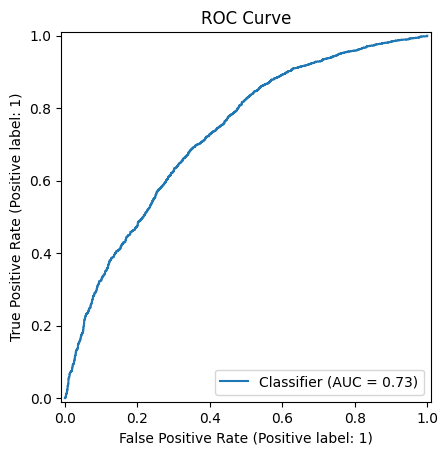

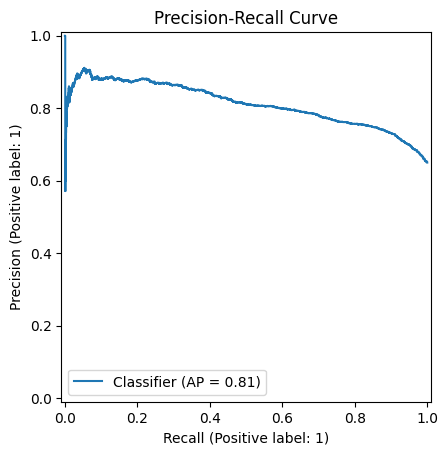

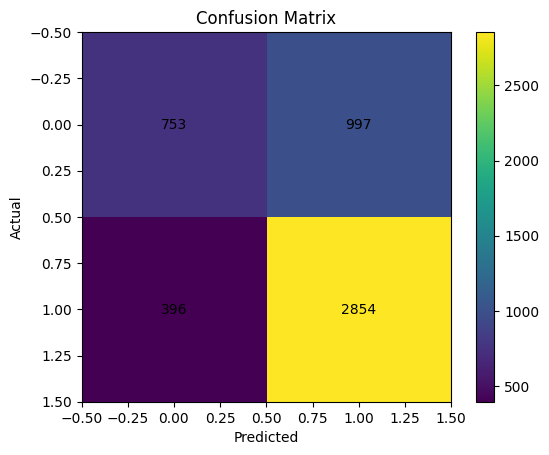

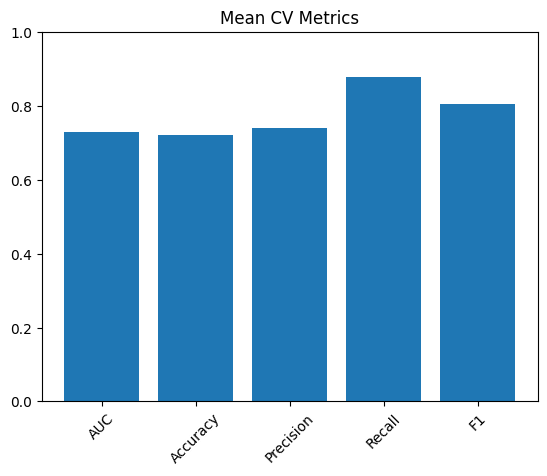

In [21]:
data = {
    "violation_type": "Forgery",
    "past_repeat_same_violation_count": 0,
    "recent_same_violation_count": 0,
    "months_since_last_same_violation": 0,
    "clean_streak_length": 0,
    "ongoing_same_violation_count": 0
}

train_model('student_violations', False, True)